In [1]:
# import required libraries
from ifmiap import utils
from ifmiap import authenticate
from ifmiap import preprocessing
import datetime

Echoing from here: /Users/pratyusht/Documents/MapSolveAI/ifmiap/ifmiap/__init__.py


/opt/homebrew/lib/python3.9/site-packages/geopandas/_compat.py:124: UserWarning: The Shapely GEOS version (3.11.1-CAPI-1.17.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
# process certain squares using a list of grid IDs
selected_grid_id = [104]
aoi_list = utils.gpd_to_json(id_list=selected_grid_id)

# define the flood date range
pre_flood_dates = utils.date_range('01/05/2020', 60)
post_flood_dates = utils.date_range('20/07/2020', 8)

# pull sentinel-1 images for pre and post flood duration
pre_s1_scenes = utils.search_sentinel_data(
    bbox = aoi_list[0], 
    start_date = pre_flood_dates[0], 
    end_date = pre_flood_dates[-1]
)
post_s1_scenes = utils.search_sentinel_data(
    bbox = aoi_list[0], 
    start_date = post_flood_dates[0], 
    end_date = post_flood_dates[-1]
)

print(f'{len(pre_s1_scenes)} pre flood scenes and {len(post_s1_scenes)} post flood scenes found.')

35 pre flood scenes and 7 post flood scenes found.


In [3]:
stacked_post = preprocessing.stack_images(post_s1_scenes, selected_grid_id)

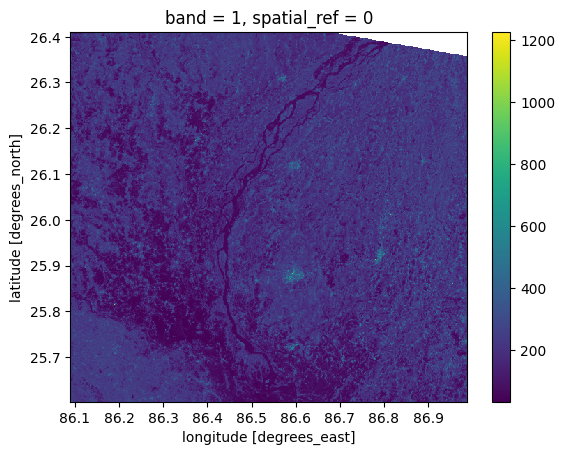

In [4]:
w = preprocessing.read_reproj_clip(post_s1_scenes[1], selected_grid_id)
w['vv_ds'].plot()

In [5]:
filename_vv = '/Users/pratyusht/Documents/MapSolveAI/ifmiap/post_vv.tif'
filename_vh = '/Users/pratyusht/Documents/MapSolveAI/ifmiap/post_vh.tif'

utils.export_xarray(stacked_post['vv_stack'], filename_vv)
utils.export_xarray(stacked_post['vh_stack'], filename_vh)